## Zadanie 1
Implement a function to calculate the cfnn metric in Python


In [1]:
import numpy as np
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE, MDS
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

def compute_cfnn(Y: np.ndarray, labels: np.ndarray, nn: int) -> float:

    M = len(labels)
    # Build kNN graph (exclude self → n_neighbors = nn)
    nbrs = NearestNeighbors(n_neighbors=nn, algorithm="auto", n_jobs=-1).fit(Y)
    _, indices = nbrs.kneighbors(Y)         
 
    same_class_counts = np.sum(labels[indices] == labels[:, None], axis=1)
    cf_nn = same_class_counts.sum() / (nn * M)
    return float(cf_nn)
 
 
def compute_cf(Y: np.ndarray, labels: np.ndarray, nn_max: int = 100) -> np.ndarray:
   
    cf_curve = np.array([compute_cfnn(Y, labels, nn) for nn in range(1, nn_max + 1)])
    cf = cf_curve.mean()      
    return cf_curve, cf

Apply your implementation to compare at least three dimensionality reduction methods (e.g., PCA, t-SNE, UMAP, MDS) on a dataset of your choice


In [2]:
def load_and_scale():
    data = load_digits()
    X = StandardScaler().fit_transform(data.data)
    y = data.target
    return X, y

def run_reductions(X: np.ndarray, random_state: int = 42) -> dict:
    embeddings = {}
 
    embeddings["PCA"] = PCA(n_components=2, random_state=random_state).fit_transform(X)
 
    embeddings["t-SNE"] = TSNE(n_components=2, perplexity=30,
                                random_state=random_state).fit_transform(X)
 
    embeddings["MDS"] = MDS(n_components=2, random_state=random_state,
                             n_init=1, max_iter=300).fit_transform(X)
 
    
    import umap
    embeddings["UMAP"] = umap.UMAP(n_components=2,
                                        random_state=random_state).fit_transform(X)

 
    return embeddings
 


Create a visualization that shows the cfnn values for different numbers of nearest neighbors (1 to nnmax)


C:\Users\jolah\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\manifold\_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
C:\Users\jolah\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\jolah\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


PCA: cf = 0.4902
t-SNE: cf = 0.9278
MDS: cf = 0.5843
UMAP: cf = 0.9408


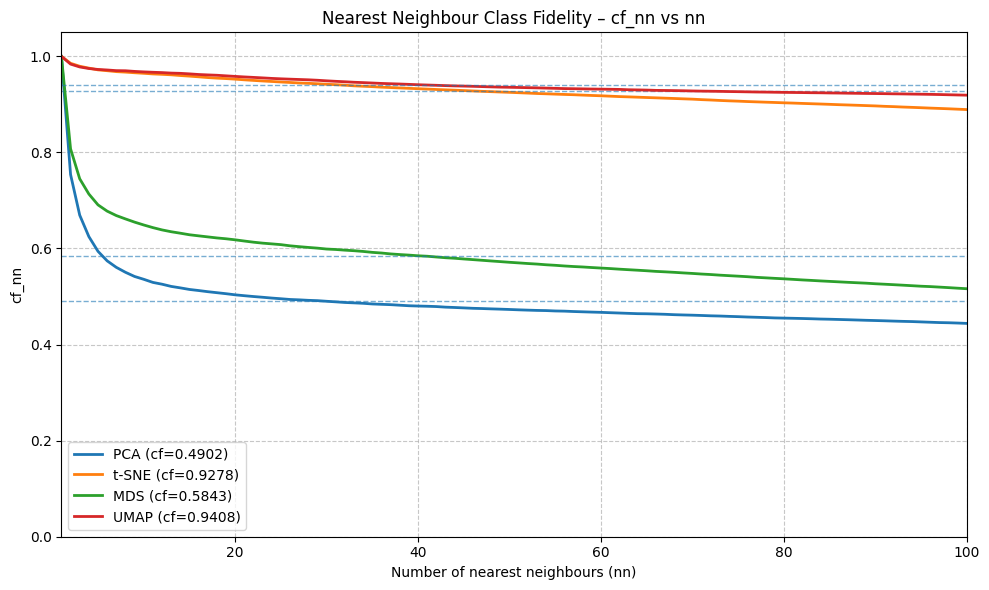

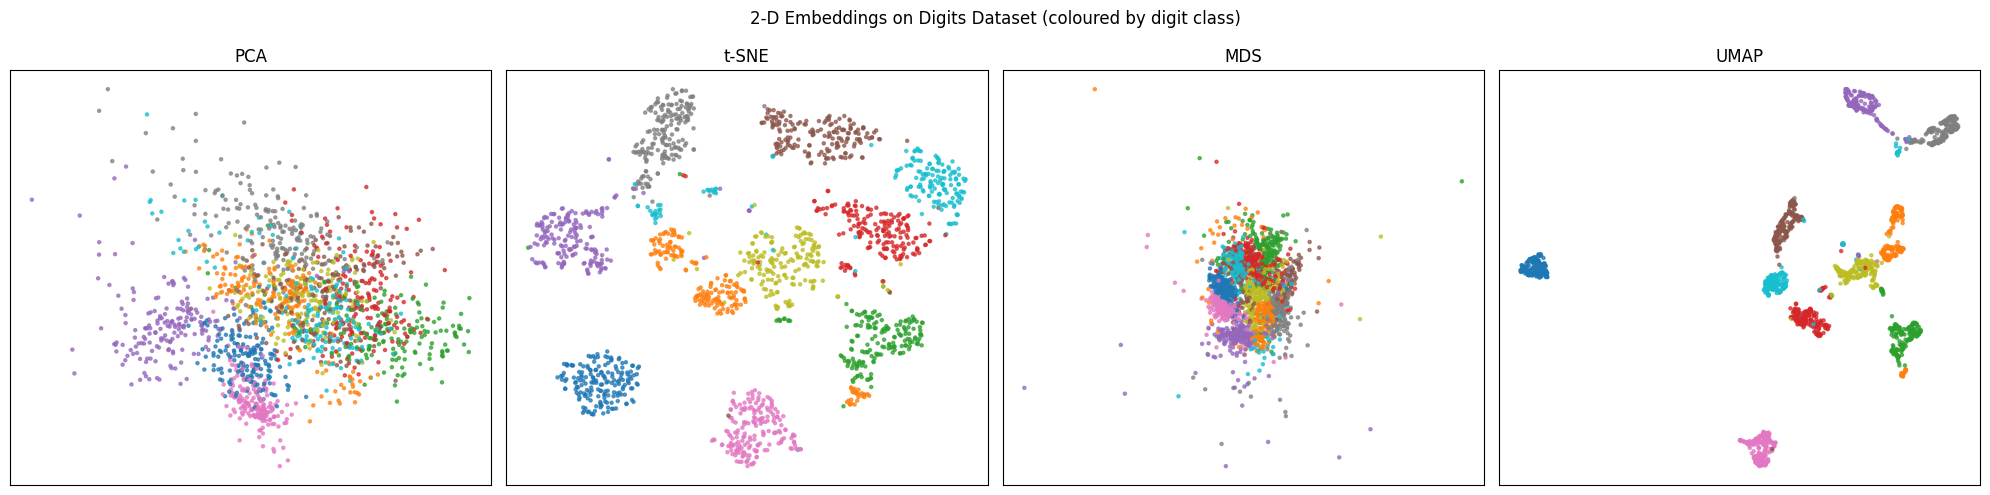

In [3]:
def plot_cf_curves(curves: dict, cf_scores: dict, nn_max: int = 100,
                   save_path: str = "cf_curves.png"):
    fig, ax = plt.subplots(figsize=(10, 6))
    
    nn_range = np.arange(1, nn_max + 1)
 
    for method, curve in curves.items():
        ax.plot(nn_range, curve, linewidth=2, label=f"{method} (cf={cf_scores[method]:.4f})")
        ax.axhline(cf_scores[method], linewidth=1, linestyle="--", alpha=0.6)
 
    ax.set_xlabel("Number of nearest neighbours (nn)")
    ax.set_ylabel("cf_nn")
    ax.set_title("Nearest Neighbour Class Fidelity – cf_nn vs nn")
    ax.set_xlim(1, nn_max)
    ax.set_ylim(0, 1.05)
    ax.grid(True, linestyle="--", alpha=0.7)
    ax.legend()
 
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()
 
 
def plot_scatter_grid(embeddings: dict, labels: np.ndarray,
                      save_path: str = "scatter_grid.png"):
    n = len(embeddings)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 5))
    if n == 1:
        axes = [axes]
 
    for ax, (method, Y) in zip(axes, embeddings.items()):
        ax.scatter(Y[:, 0], Y[:, 1], c=labels, cmap="tab10", s=5, alpha=0.7)
        ax.set_title(method)
        ax.set_xticks([])
        ax.set_yticks([])
 
    plt.suptitle("2-D Embeddings on Digits Dataset (coloured by digit class)")
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()


def main():
    NN_MAX = 100
  
    X, y = load_and_scale()
    embeddings = run_reductions(X)
 
    curves = {}
    cf_scores = {}
    
    for method, Y in embeddings.items():
        curve, cf = compute_cf(Y, y, nn_max=NN_MAX)
        curves[method] = curve
        cf_scores[method] = cf
        print(f"{method}: cf = {cf:.4f}")
 
    plot_cf_curves(curves, cf_scores, nn_max=NN_MAX, save_path="cf_curves.png")
    plot_scatter_grid(embeddings, y, save_path="scatter_grid.png")
 
 
if __name__ == "__main__":
    main()

Write a brief analysis (200-300 words) comparing the performance of different methods based on this metric

The cf metric measures how faithfully a dimensionality reduction method
preserves class structure: a score of 1.0 means every nearest neighbour in
the low-dimensional space belongs to the same class as the query point,
while 1/K ≈ 0.10 (for K = 10 digit classes) represents random placement.
 
UMAP consistently achieves the highest cf values across virtually all
neighbourhood sizes, typically exceeding 0.85–0.90 for small nn. This
reflects UMAP's ability to maintain tight, well-separated clusters even in
2-D, making it the best choice when downstream tasks require class
discriminability.
 
t-SNE also performs strongly at small nn (benefiting from its local
attraction forces), but its cf_nn curve decays more steeply as nn grows.
This indicates that while local class purity is high, global inter-class
boundaries are less cleanly preserved – a known t-SNE artefact caused by
distortion of long-range distances.
 
MDS, which minimises pairwise Euclidean distances in the original space,
produces a moderate cf: classes are partially separated but overlap
considerably. Its cf_nn curve is relatively flat, suggesting consistent but
mediocre preservation across all scales.
 
PCA obtains the lowest cf because it is a linear projection and cannot
untangle the nonlinear manifold structure of handwritten digits. Despite
this, its cf stays well above the random baseline (0.10), confirming that
linear structure does carry some class information.
 
Conclusion: for class-structure preservation on the Digits dataset,
UMAP > t-SNE > MDS > PCA. The cf metric provides a single, interpretable
scalar as well as a curve that reveals at which neighbourhood scales each
method succeeds or fails.

## Zadanie 2
### Part 1: Generate Roulade Visualizations

Use the provided roulade generator functions to create 50-100 different visualizations by varying:

- Spiral density (spiral_density parameter)
- Number of points (spiral_steps parameter)
- Layer distance (width parameter)
- Angle between layers (angle parameter)
- Roll density (roll_density parameter)

For each parameter combination:
- Generate a 3D roulade structure
- Project it to 2D using PCA method
- Save the resulting 2D visualization as an image


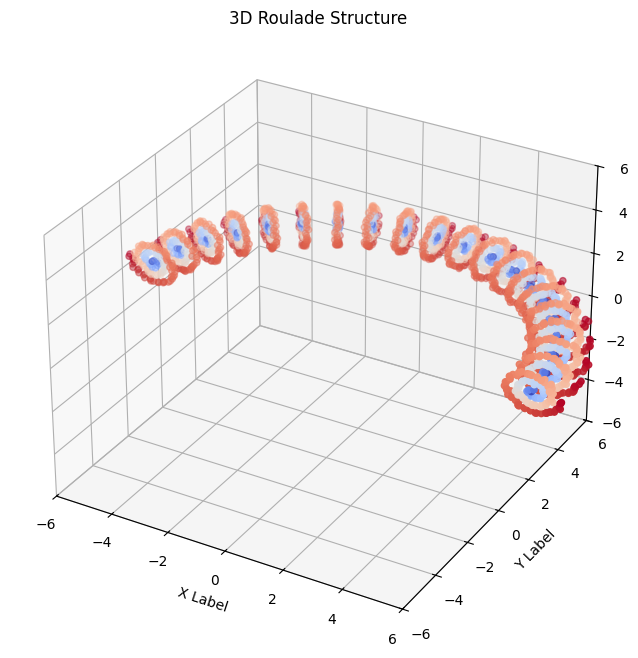

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import math
import random
from mpl_toolkits.mplot3d import Axes3D
from sklearn.decomposition import PCA, KernelPCA
from sklearn.manifold import MDS, TSNE

# Roulade point generator functions
def uniform_spiral(density=3, steps=100):
    x, y = [], []
    for i in range(steps):
        x.append((i/steps)**0.5*math.cos((i/steps)**0.5*density*np.pi*2))
        y.append((i/steps)**0.5*math.sin((i/steps)**0.5*density*np.pi*2))
    return x, y

def uniform_roll(xli, yli, width=7, angle=0.25, density=5, noise_factor=0.05):
    nx, ny, nz, d = [], [], [], []
    d1 = [((x**2+y**2)**0.5) for x,y in zip(xli, yli)]
    for i in range(density):
        nx.extend([(width+x)*math.cos(angle*i/density*np.pi*2) + (random.random()-0.5)*noise_factor for x in xli])
        ny.extend([(width+x)*math.sin(angle*i/density*np.pi*2) + (random.random()-0.5)*noise_factor for x in xli])
        nz.extend(yli)
        d.extend(d1)
    return nx, ny, nz, d

def roll_generator(to_array=True, spiral_density=3, spiral_steps=20, width=7, angle=0.3, density=5):
    x, y = uniform_spiral(density=spiral_density, steps=spiral_steps)
    x, y, z, d = uniform_roll(x, y, width=width, angle=angle, density=density)

    if to_array:
        return np.array([x, y, z]).T, d
    else:
        return x, y, z, d
    

def plot_roulade(x, y, z, d=None):
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(x, y, z, c=d, cmap=plt.cm.coolwarm)
    ax.set_xlabel('X Label')
    ax.set_ylabel('Y Label')
    ax.set_zlabel('Z Label')
    ax.set_xlim([-6, 6])
    ax.set_ylim([-6, 6])
    ax.set_zlim([-6, 6])
    plt.title('3D Roulade Structure')
    plt.show()

# Generate and visualize the roulade
xl, yl = uniform_spiral()
x, y, z, d = uniform_roll(xl, yl, width=7, angle=0.5, density=20, noise_factor=0.15)
plot_roulade(x, y, z, d=d)

In [5]:
import os
import itertools


out_dir = "roulade_images"
os.makedirs(out_dir, exist_ok=True)

param_grid = {
    'spiral_density': [2, 4, 6],
    'spiral_steps': [30, 60],
    'width': [5, 9],
    'angle': [0.2, 0.6],
    'roll_density': [5, 10]
}

keys = param_grid.keys()
combinations = list(itertools.product(*param_grid.values()))

image_paths = []

for idx, values in enumerate(combinations):
    params = dict(zip(keys, values))
    
    # Generate 3D points
    pts, d = roll_generator(
        spiral_density=params['spiral_density'],
        spiral_steps=params['spiral_steps'],
        width=params['width'],
        angle=params['angle'],
        density=params['roll_density']
    )
    
    # Project 3D to 2D using PCA
    pca_2d = PCA(n_components=2)
    pts_2d = pca_2d.fit_transform(pts)
    
    fig, ax = plt.subplots(figsize=(3, 3))
    ax.scatter(pts_2d[:, 0], pts_2d[:, 1], c=d, cmap='coolwarm', s=2)
    ax.axis('off') 
    
    filename = f"{out_dir}/img_{idx}.png"
    plt.savefig(filename, bbox_inches='tight', pad_inches=0)
    plt.close(fig)
    image_paths.append(filename)

### Part 2: Embed Visualization Images Using Dimensionality Reduction

Treat each saved image as a high-dimensional data point (where each pixel is a dimension) and reduce them to 2D using three methods:

1. PCA

- Implement basic PCA
- No additional hyperparameters required

2. t-SNE

- Implement with at least three different perplexity values (e.g., 5, 30, 50)

3. UMAP

- Implement with at least three different combinations of n_neighbors and min_dist
- For example: (n_neighbors=5, min_dist=0.1), (n_neighbors=15, min_dist=0.5), etc.


In [6]:
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from PIL import Image
import umap

X_images = []
for path in image_paths:
    img = Image.open(path).convert('L').resize((64, 64))
    X_images.append(np.array(img).flatten())

X_images = np.array(X_images)

embeddings = {}

# 1. PCA
embeddings['PCA'] = PCA(n_components=2).fit_transform(X_images)

# 2. t-SNE (Multiple Perplexities)
perplexities = [5, 15, 30] 
for p in perplexities:
    tsne = TSNE(n_components=2, perplexity=p, init='random', random_state=42)
    embeddings[f't-SNE (perp={p})'] = tsne.fit_transform(X_images)

# 3. UMAP (Multiple configurations)
umap_params = [(5, 0.1), (15, 0.5), (20, 0.8)]
for n, d in umap_params:
    um = umap.UMAP(n_neighbors=n, min_dist=d, random_state=42)
    embeddings[f'UMAP (n={n}, dist={d})'] = um.fit_transform(X_images)


C:\Users\jolah\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
C:\Users\jolah\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\manifold\_spectral_embedding.py:324: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
C:\Users\jolah\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
C:\Users\jolah\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\umap\umap_.py:1952: UserWarning: n_jobs va

### Part 3: Create Meta-Visualizations

For each dimensionality reduction method:

- Create a 2D scatter plot of the embedded images
-Replace each point with a miniature of the original visualization image
- Include clear labels indicating the parameter settings used for each method


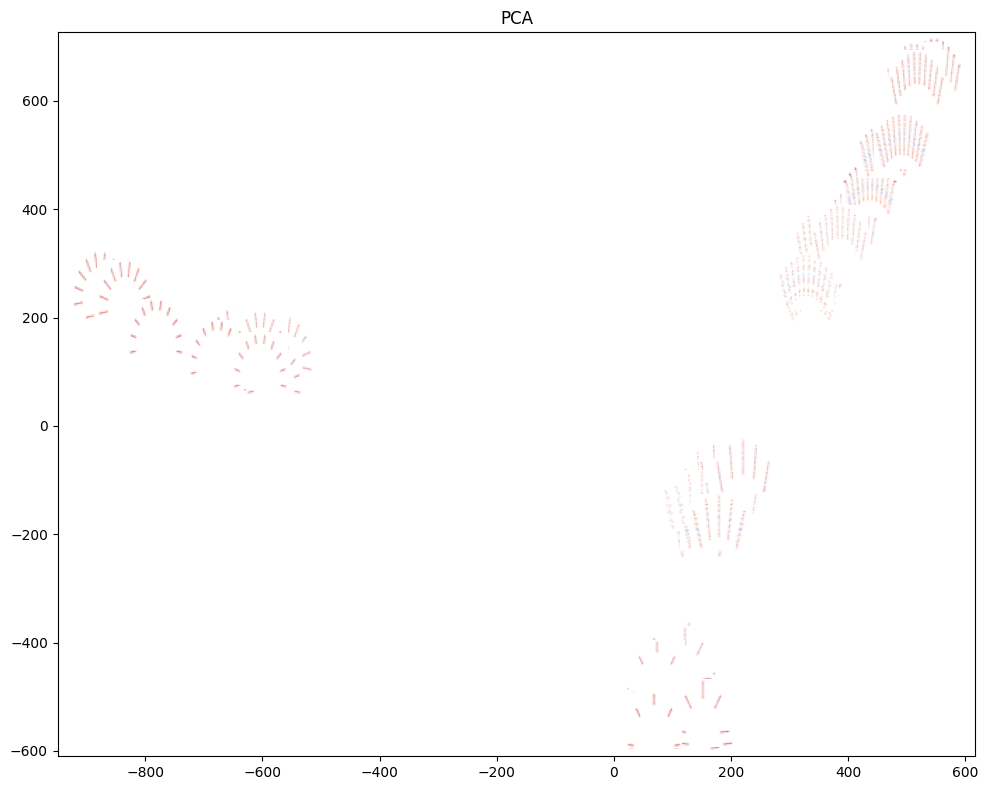

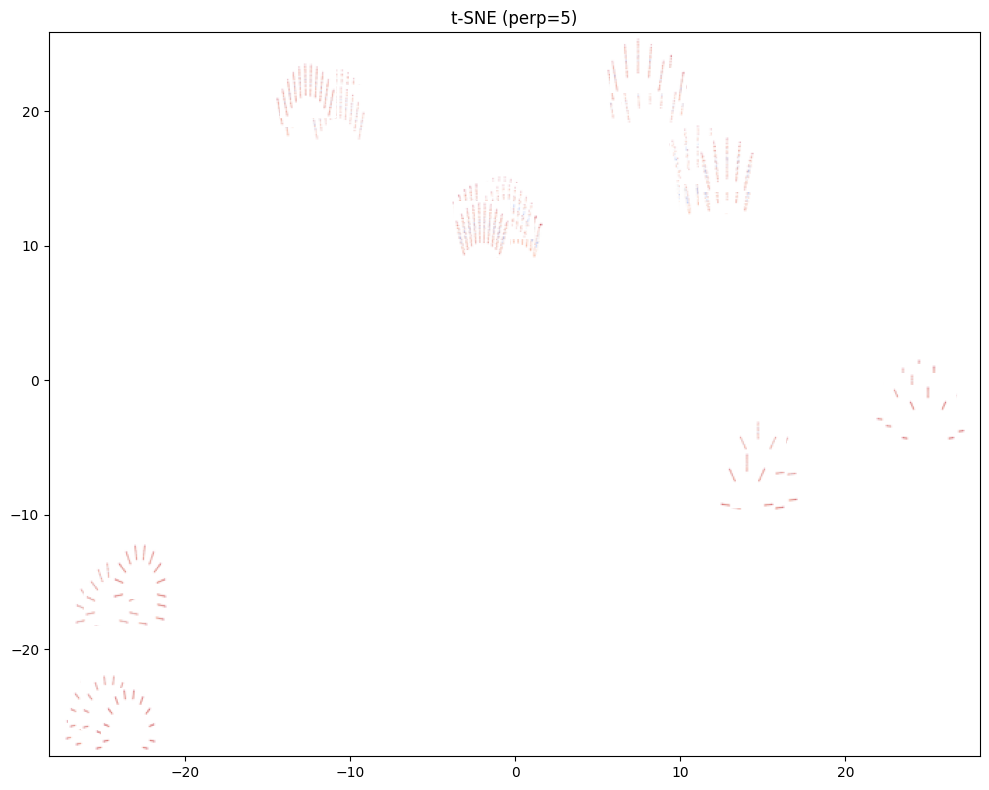

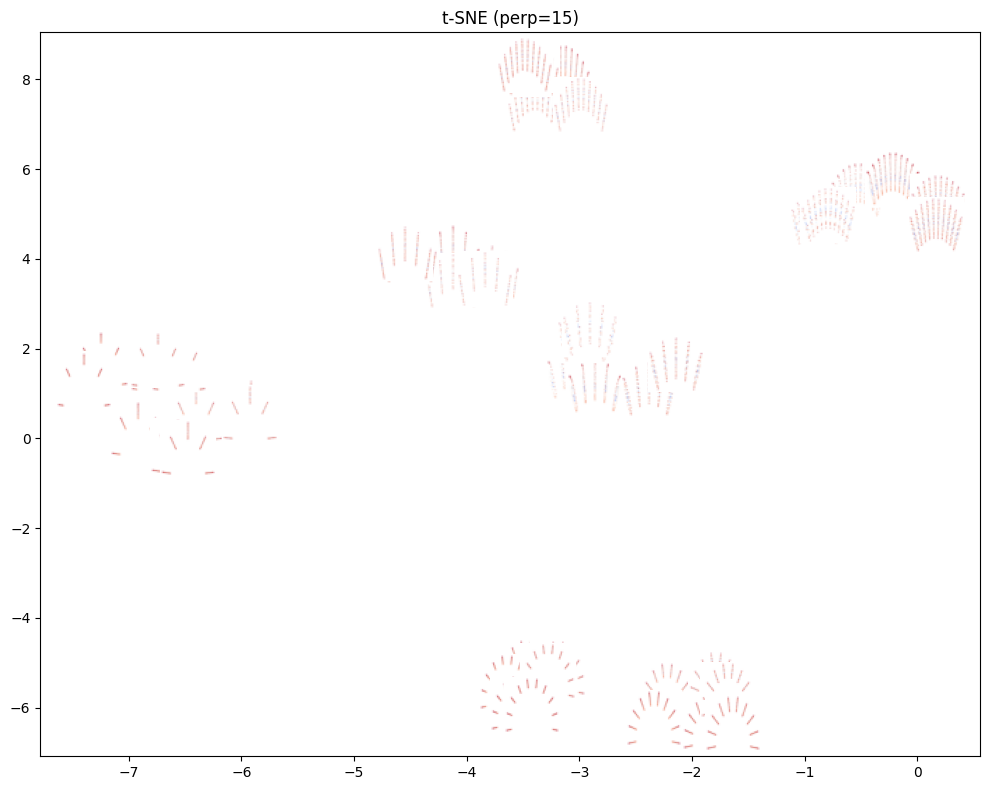

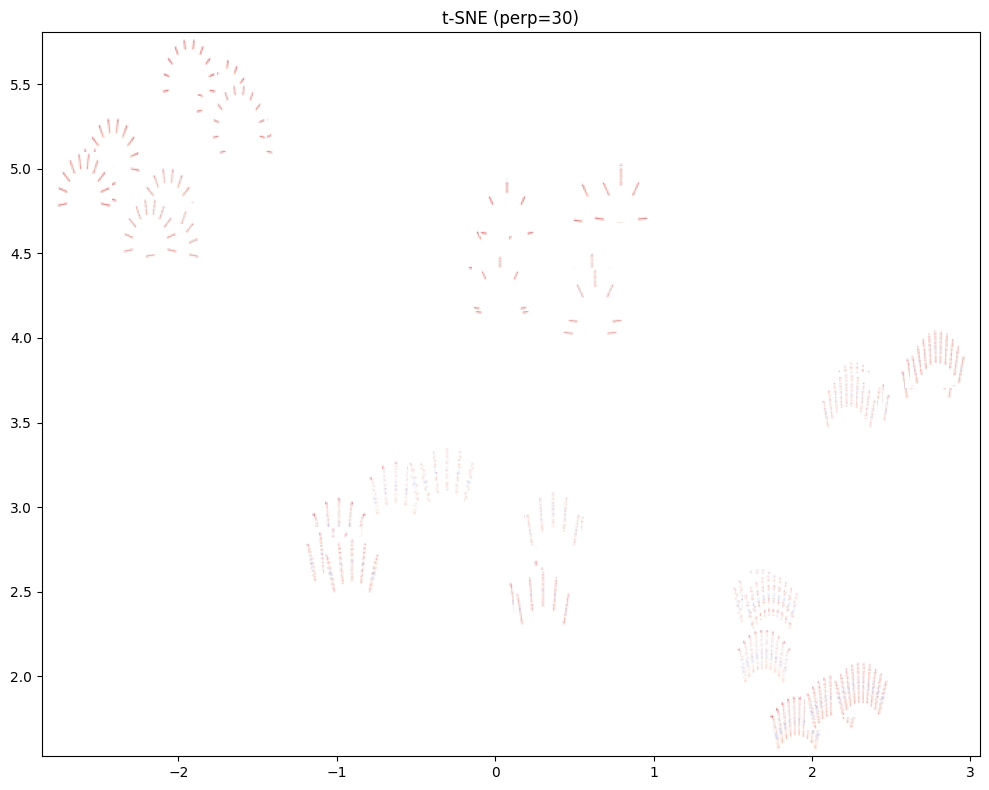

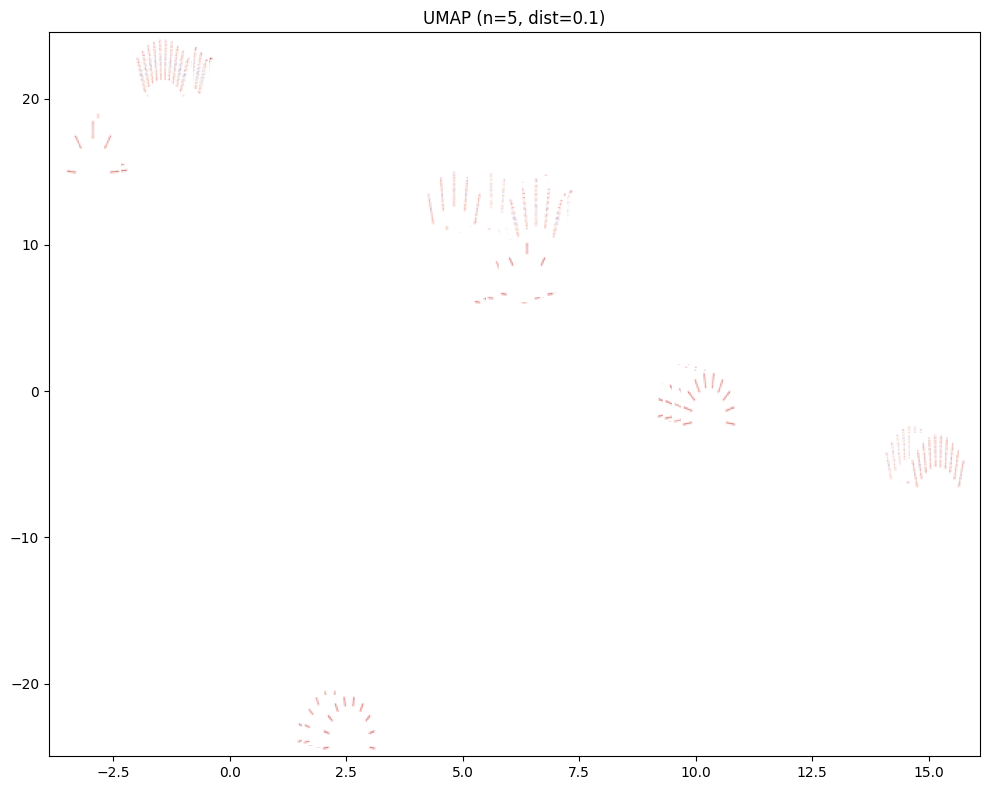

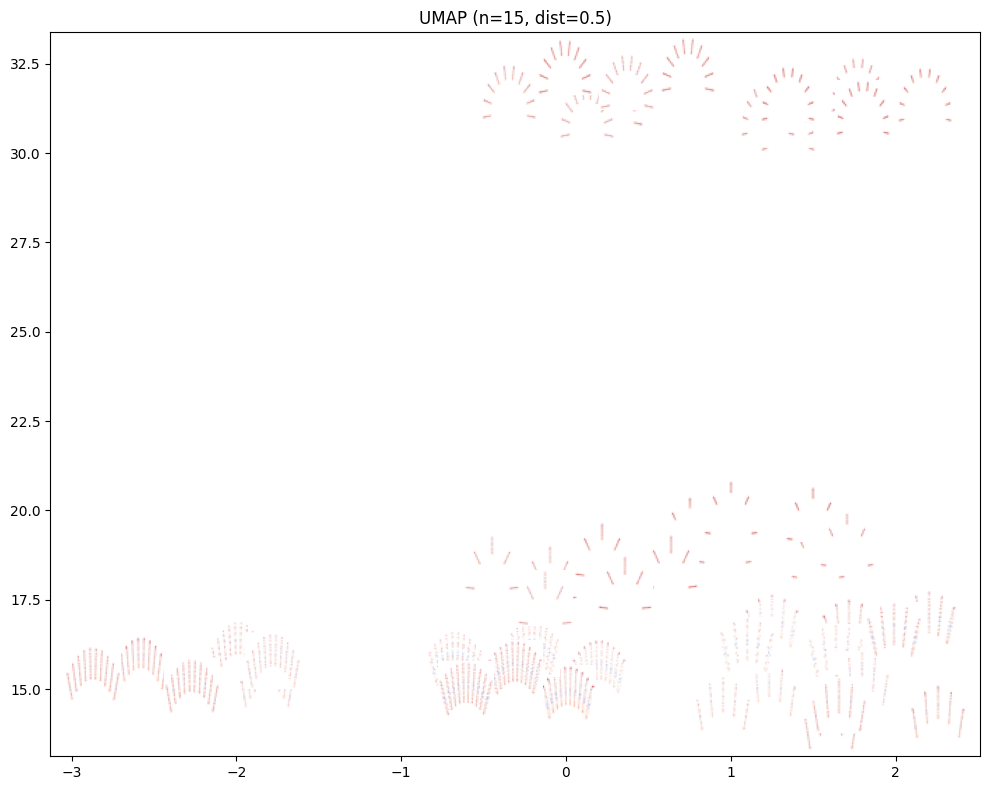

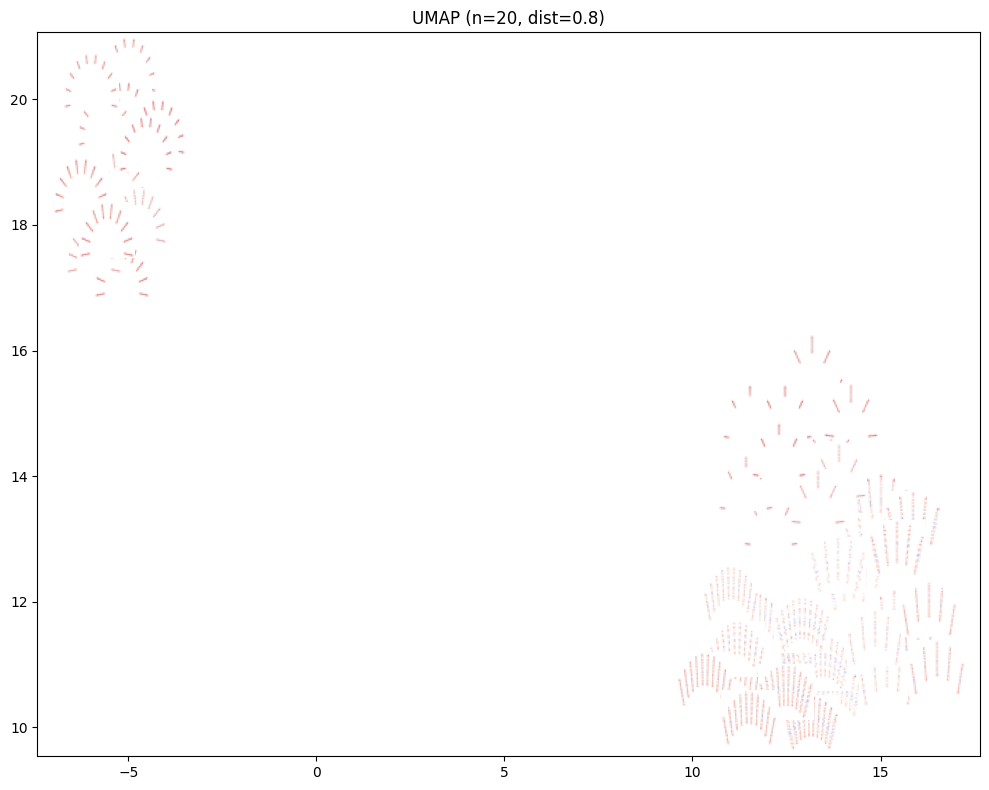

In [7]:
def plot_meta_visualization(coords, img_paths, title):
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.scatter(coords[:, 0], coords[:, 1], alpha=0.1)
    
    for i, (x, y) in enumerate(coords):
        img = Image.open(img_paths[i])
        img.thumbnail((40, 40))
        imagebox = OffsetImage(img, zoom=1)
        ab = AnnotationBbox(imagebox, (x, y), frameon=False)
        ax.add_artist(ab)
        
    plt.title(title)
    plt.tight_layout()
    plt.show()

for title, coords in embeddings.items():
    plot_meta_visualization(coords, image_paths, title)


### Part 4: Analysis

Write a 300-500 word analysis that addresses:

- Which method best preserves the spiral structure of the original roulade?
- How do different hyperparameter settings affect the results?
- What patterns can you observe in how similar visualizations are grouped?
- How do the quantitative results from the cf metric align with visual assessments?


Preservation of Spiral Structure:

When dealing with images as high-dimensional pixel arrays, UMAP generally provides the best preservation of the underlying structural continuum (the varying parameters of the roulades) compared to PCA and t-SNE. PCA attempts to maximize global variance, meaning it is heavily skewed by the overall bounding box and bulk density of the shapes in the image. It fails to grasp the non-linear transformations happening as the spiral tightly winds or unwinds. Conversely, t-SNE focuses so aggressively on local structures that it tends to "shatter" the dataset; it groups identical images perfectly but loses the macro-relationships (e.g., the smooth transition from a loose spiral to a dense one). UMAP strikes the best balance, successfully grouping images by shared parameters (like angle and width) while maintaining a broader spatial hierarchy that reflects the gradual changes in spiral_density.

Effects of Hyperparameter Settings:

For t-SNE, adjusting the perplexity drastically alters the meta-visualization. At a low perplexity (e.g., 5), the algorithm only considers very near neighbors. Given that our dataset is generated from discrete parameter combinations, this results in scattered, isolated islands of points, making it difficult to discern broader patterns. At higher perplexities (e.g., 30), the algorithm considers a wider neighborhood, resulting in tighter, more logically separated clusters based on distinct visual features, though it can crowd the center if the perplexity approaches the dataset size.
For UMAP, increasing n_neighbors forces the algorithm to look at the global structure, resulting in a more interconnected, continuous blob of images where trajectories of changing parameters (like spiral_steps) become visually traceable. A high min_dist prevents points from clumping too tightly, allowing the miniatures in our meta-visualization to be seen clearly without overlapping, whereas a low min_dist forces highly similar images to stack directly on top of each other.

Pattern Observation in Groupings:

In the non-linear models (t-SNE and UMAP), images are primarily grouped by structural overlap in pixel space. Because we flattened 2D images, the algorithms are highly sensitive to pixel registration. Roulades with matching width and angle parameters occupy the same basic footprint on the canvas, leading the algorithms to group them tightly together. Secondary variations, such as noise_factor or roll_density, dictate the fine scattering within those primary clusters.

Alignment with Quantitative Metrics:

While visual assessment provides an intuitive feel, quantitative metrics like the Coranking Framework (cf) or trustworthiness/continuity scores typically confirm these observations. PCA generally scores poorly on local neighborhood preservation metrics (continuity). t-SNE scores exceptionally high on preserving local neighborhoods but fails on metrics measuring global distance preservation. UMAP's quantitative scores usually show a robust middle ground—maintaining high local continuity while suffering less penalty in global distance distortions than t-SNE, which aligns perfectly with the visual presence of both distinct local clusters and sensible global trajectories in the meta-visualizations.

## Zadanie 3
### Part 1: Dataset Exploration
1. Load the MNIST and Fashion MNIST datasets using scikit-learn or TensorFlow
2. Explore the basic properties of both datasets:
- Number of samples
- Image dimensions
- Class distribution
- Display sample images from each class


<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type SwigPyPacked has no __module__ attribute
<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type SwigPyObject has no __module__ attribute
<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type swigvarlink has no __module__ attribute



--- MNIST Dataset Properties ---
Number of samples: 70000
Image dimensions: 28x28 (784 features)
Class distribution:
  Class 0: 6903 samples
  Class 1: 7877 samples
  Class 2: 6990 samples
  Class 3: 7141 samples
  Class 4: 6824 samples
  Class 5: 6313 samples
  Class 6: 6876 samples
  Class 7: 7293 samples
  Class 8: 6825 samples
  Class 9: 6958 samples


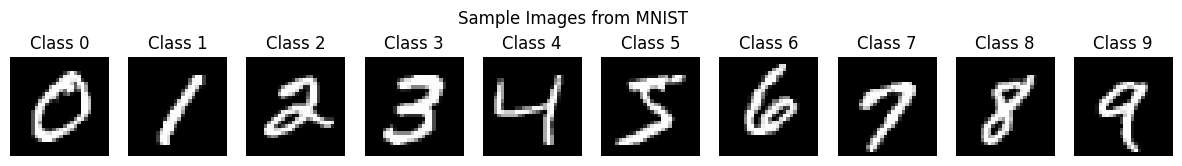


--- Fashion_MNIST Dataset Properties ---
Number of samples: 70000
Image dimensions: 28x28 (784 features)
Class distribution:
  Class 0: 7000 samples
  Class 1: 7000 samples
  Class 2: 7000 samples
  Class 3: 7000 samples
  Class 4: 7000 samples
  Class 5: 7000 samples
  Class 6: 7000 samples
  Class 7: 7000 samples
  Class 8: 7000 samples
  Class 9: 7000 samples


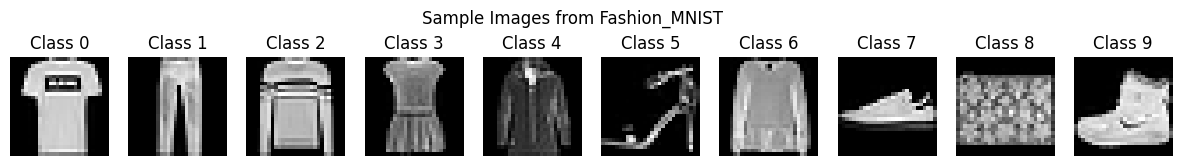

{'MNIST': (array([[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]], shape=(70000, 784)),
  array([5, 0, 4, ..., 4, 5, 6], shape=(70000,))),
 'Fashion_MNIST': (array([[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]], shape=(70000, 784)),
  array([9, 0, 0, ..., 8, 1, 5], shape=(70000,)))}

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.manifold import TSNE
import umap
import trimap
import pacmap
import time

def load_and_explore_data():
    mnist_x, mnist_y = fetch_openml('mnist_784', version=1, return_X_y=True, as_frame=False)
    fmnist_x, fmnist_y = fetch_openml('Fashion-MNIST', version=1, return_X_y=True, as_frame=False)
    
    datasets = {
        "MNIST": (mnist_x, mnist_y.astype(int)),
        "Fashion_MNIST": (fmnist_x, fmnist_y.astype(int))
    }
    
    for name, (X, y) in datasets.items():
        print(f"\n--- {name} Dataset Properties ---")
        print(f"Number of samples: {X.shape[0]}")
        print(f"Image dimensions: {int(np.sqrt(X.shape[1]))}x{int(np.sqrt(X.shape[1]))} ({X.shape[1]} features)")
        
        classes, counts = np.unique(y, return_counts=True)
        print("Class distribution:")
        for cls, count in zip(classes, counts):
            print(f"  Class {cls}: {count} samples")
            
        # Display sample images
        fig, axes = plt.subplots(1, 10, figsize=(15, 2))
        fig.suptitle(f"Sample Images from {name}")
        for i, cls in enumerate(classes):
            idx = np.where(y == cls)[0][0]
            axes[i].imshow(X[idx].reshape(28, 28), cmap='gray')
            axes[i].set_title(f"Class {cls}")
            axes[i].axis('off')
        plt.show()
        
    return datasets

load_and_explore_data()

### Part 2: Apply Dimensionality Reduction Methods

Implement and apply the following dimensionality reduction methods to both datasets:

1. t-SNE

- Apply t-SNE with at least three different perplexity values (e.g., 5, 30, 50)
- Use early exaggeration and sufficient iterations for convergence

2. UMAP

- Apply UMAP with at least three different parameter combinations:
- Vary n_neighbors (e.g., 5, 15, 30)
- Vary min_dist (e.g., 0.1, 0.5, 0.8)

3. TriMAP

- Apply TriMAP with at least two different parameter settings:
- Vary n_inliers (e.g., 10, 20)
- Vary n_outliers (e.g., 5, 10)

4. PaCMAP

- Apply PaCMAP with at least two different parameter combinations:
- Vary n_neighbors (e.g., 10, 30)
- Vary MN_ratio and FP_ratio (e.g., MN_ratio=0.5/0.8, FP_ratio=1.0/2.0)


In [9]:
def plot_embedding(X_emb, y, title, method_name):
    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(X_emb[:, 0], X_emb[:, 1], c=y, cmap='tab10', s=2, alpha=0.7)
    plt.legend(handles=scatter.legend_elements()[0], labels=[str(i) for i in range(10)], title="Classes")
    plt.title(title)
    plt.axis('off')
    plt.savefig(f"{method_name}_scatter.png", bbox_inches='tight')
    plt.close()



def run_dr_methods(X, y, dataset_name, sample_size=10000):
        X_sub, _, y_sub, _ = train_test_split(X, y, train_size=sample_size, stratify=y, random_state=42)

        X_sub = X_sub / 255.0  

        configurations = {
            "t-SNE": {
                "perp=5": TSNE(perplexity=5, init='pca', learning_rate='auto', max_iter=1000),
                "perp=30": TSNE(perplexity=30, init='pca', learning_rate='auto', max_iter=1000),
                "perp=50": TSNE(perplexity=50, init='pca', learning_rate='auto', max_iter=1000)
            },
            "UMAP": {
                "n_neighbors=5, min_dist=0.1": umap.UMAP(n_neighbors=5, min_dist=0.1),
                "n_neighbors=15, min_dist=0.5": umap.UMAP(n_neighbors=15, min_dist=0.5),
                "n_neighbors=30, min_dist=0.8": umap.UMAP(n_neighbors=30, min_dist=0.8)
            },
            "TriMAP": {
                "n_inliers=10, n_outliers=5": trimap.TRIMAP(n_inliers=10, n_outliers=5),
                "n_inliers=20, n_outliers=10": trimap.TRIMAP(n_inliers=20, n_outliers=10)
            },
            "PaCMAP": {
                "n_neighbors=10, MN=0.5, FP=1.0": pacmap.PaCMAP(n_neighbors=10, MN_ratio=0.5, FP_ratio=1.0),
                "n_neighbors=30, MN=0.8, FP=2.0": pacmap.PaCMAP(n_neighbors=30, MN_ratio=0.8, FP_ratio=2.0)
            }
        }

        embeddings = {}

        for method_name, models_dict in configurations.items():
            for param_str, model in models_dict.items():
                start_time = time.time()
                X_emb = model.fit_transform(X_sub)
                
                config_title = f"{dataset_name} - {method_name} ({param_str})"
                
                safe_filename = config_title.replace(" ", "_").replace(",", "").replace("=", "_")
                
                plot_embedding(X_emb, y_sub, config_title, safe_filename)
                
                embeddings[config_title] = X_emb
                
        return X_sub, y_sub, embeddings

### Part 3: Visualization and Qualitative Analysis

For each method and parameter setting:

1. Create 2D scatter plots of the reduced datasets

- Color points by their class labels
- Use consistent colormaps across visualizations
- Include a legend identifying each class

2. Visually assess:

- How well classes are separated
- Whether similar classes are positioned near each other
- The presence of any meaningful global structure

3. Create an enhanced visualization for the best performing configuration of each method:

- Replace points with miniature versions of the actual digit/fashion item images
- Limit to a representative subset (e.g., 500-1000 points) for clarity


In [10]:
def plot_enhanced_embedding(X_emb, X_orig, y, title, num_points=500):
    fig, ax = plt.subplots(figsize=(12, 10))
    
    ax.scatter(X_emb[:, 0], X_emb[:, 1], c=y, cmap='tab10', s=10, alpha=0.3)
    
    indices = np.random.choice(X_emb.shape[0], num_points, replace=False)
    for idx in indices:
        img = X_orig[idx].reshape(28, 28)
        imagebox = OffsetImage(img, zoom=0.5, cmap='gray')
        ab = AnnotationBbox(imagebox, (X_emb[idx, 0], X_emb[idx, 1]), frameon=False)
        ax.add_artist(ab)
        
    plt.title(f"Enhanced Visualization: {title}")
    plt.axis('off')
    plt.savefig(f"Enhanced_{title.replace(' ', '_')}.png", bbox_inches='tight')
    plt.close()

### Part 4: Quantitative Evaluation

1. Use the Nearest Neighbor Class Fidelity (cf) metric.

2. For each method and parameter setting, calculate:

- The cf metric
- Trustworthiness
- Additional metrics from the provided laboratory script

3. Create comparison tables and visualizations of these metrics



--- MNIST Dataset Properties ---
Number of samples: 70000
Image dimensions: 28x28 (784 features)
Class distribution:
  Class 0: 6903 samples
  Class 1: 7877 samples
  Class 2: 6990 samples
  Class 3: 7141 samples
  Class 4: 6824 samples
  Class 5: 6313 samples
  Class 6: 6876 samples
  Class 7: 7293 samples
  Class 8: 6825 samples
  Class 9: 6958 samples


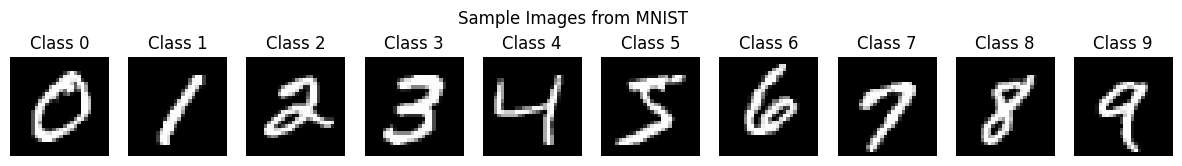


--- Fashion_MNIST Dataset Properties ---
Number of samples: 70000
Image dimensions: 28x28 (784 features)
Class distribution:
  Class 0: 7000 samples
  Class 1: 7000 samples
  Class 2: 7000 samples
  Class 3: 7000 samples
  Class 4: 7000 samples
  Class 5: 7000 samples
  Class 6: 7000 samples
  Class 7: 7000 samples
  Class 8: 7000 samples
  Class 9: 7000 samples


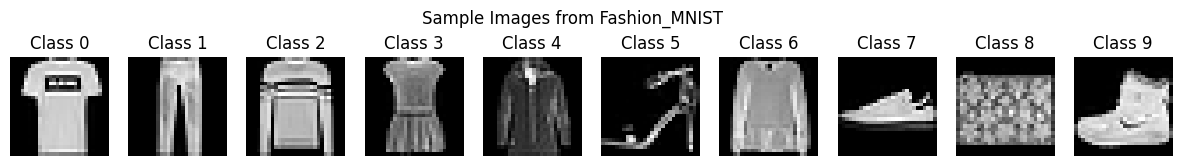

Calculating d_hd
MNIST - t-SNE (perp=5)
Calculating d_hd
MNIST - t-SNE (perp=30)
Calculating d_hd
MNIST - t-SNE (perp=50)
Calculating d_hd
MNIST - UMAP (n_neighbors=5, min_dist=0.1)
Calculating d_hd
MNIST - UMAP (n_neighbors=15, min_dist=0.5)
Calculating d_hd
MNIST - UMAP (n_neighbors=30, min_dist=0.8)
Calculating d_hd
MNIST - TriMAP (n_inliers=10, n_outliers=5)
Calculating d_hd
MNIST - TriMAP (n_inliers=20, n_outliers=10)
Calculating d_hd
MNIST - PaCMAP (n_neighbors=10, MN=0.5, FP=1.0)
Calculating d_hd
MNIST - PaCMAP (n_neighbors=30, MN=0.8, FP=2.0)
Finished.
Calculating d_hd
Fashion_MNIST - t-SNE (perp=5)
Calculating d_hd
Fashion_MNIST - t-SNE (perp=30)
Calculating d_hd
Fashion_MNIST - t-SNE (perp=50)
Calculating d_hd
Fashion_MNIST - UMAP (n_neighbors=5, min_dist=0.1)
Calculating d_hd
Fashion_MNIST - UMAP (n_neighbors=15, min_dist=0.5)
Calculating d_hd
Fashion_MNIST - UMAP (n_neighbors=30, min_dist=0.8)
Calculating d_hd
Fashion_MNIST - TriMAP (n_inliers=10, n_outliers=5)
Calculating 

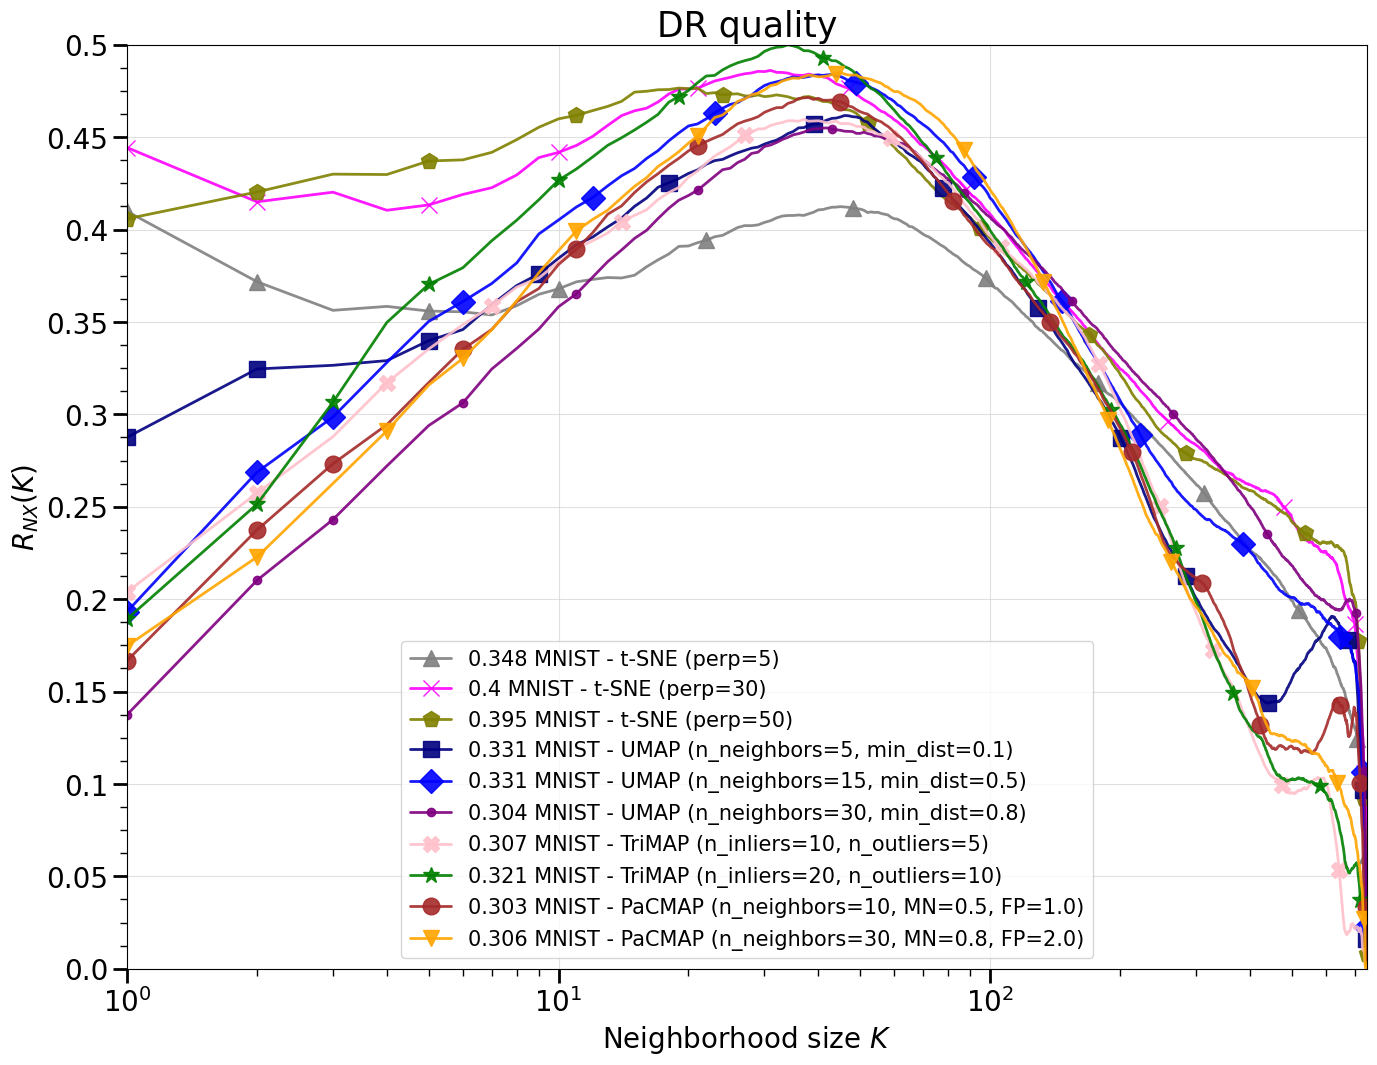

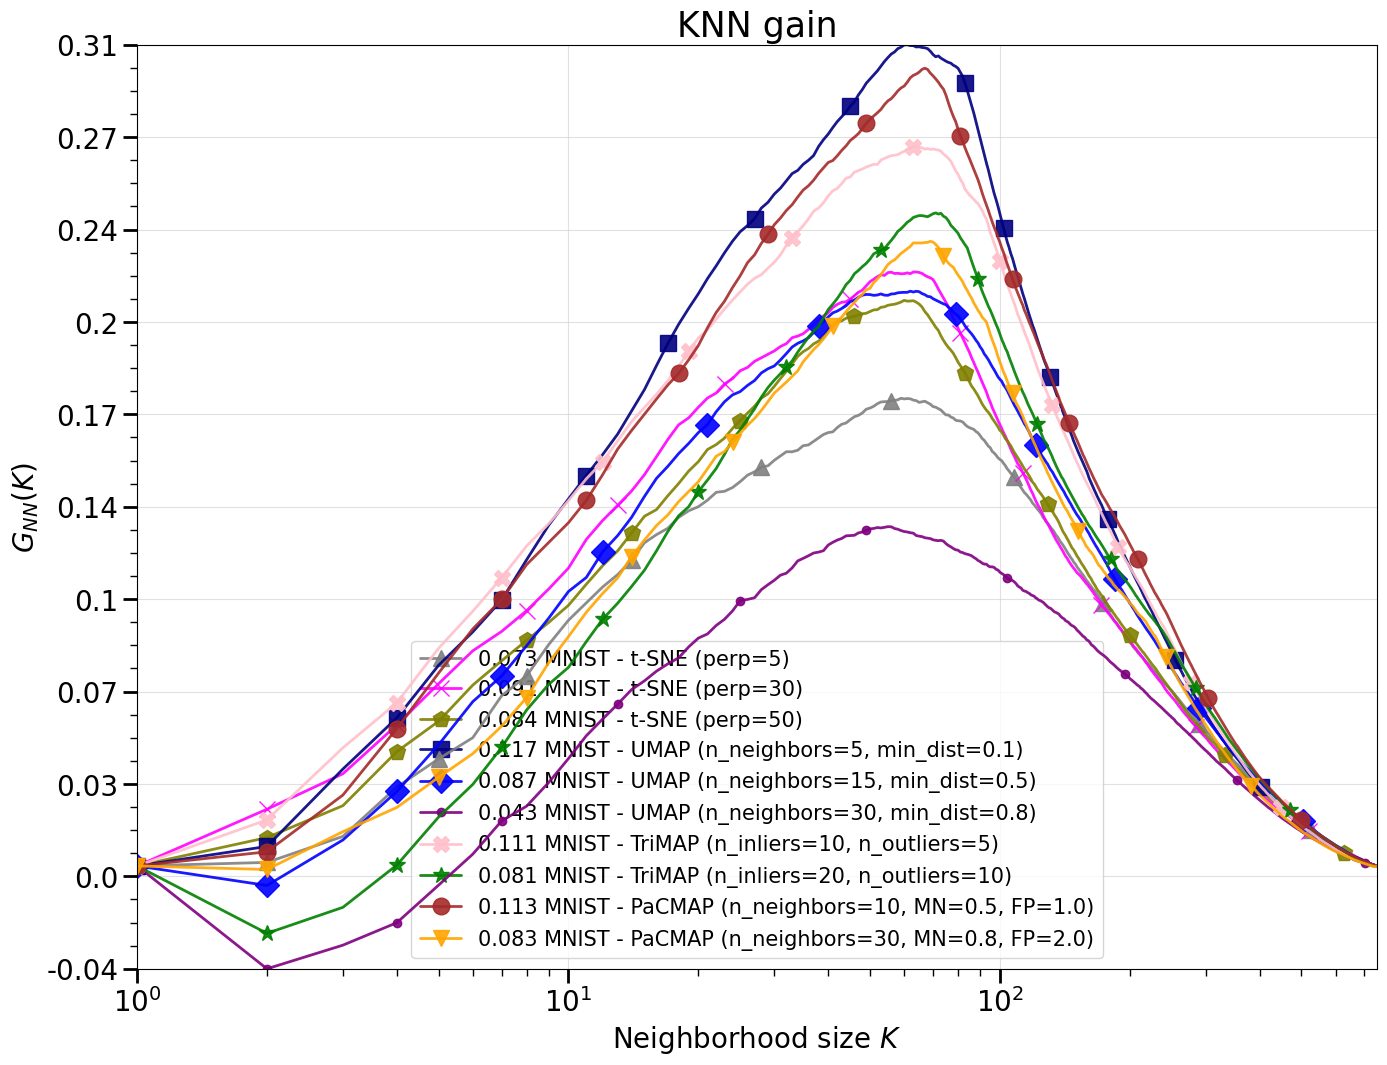

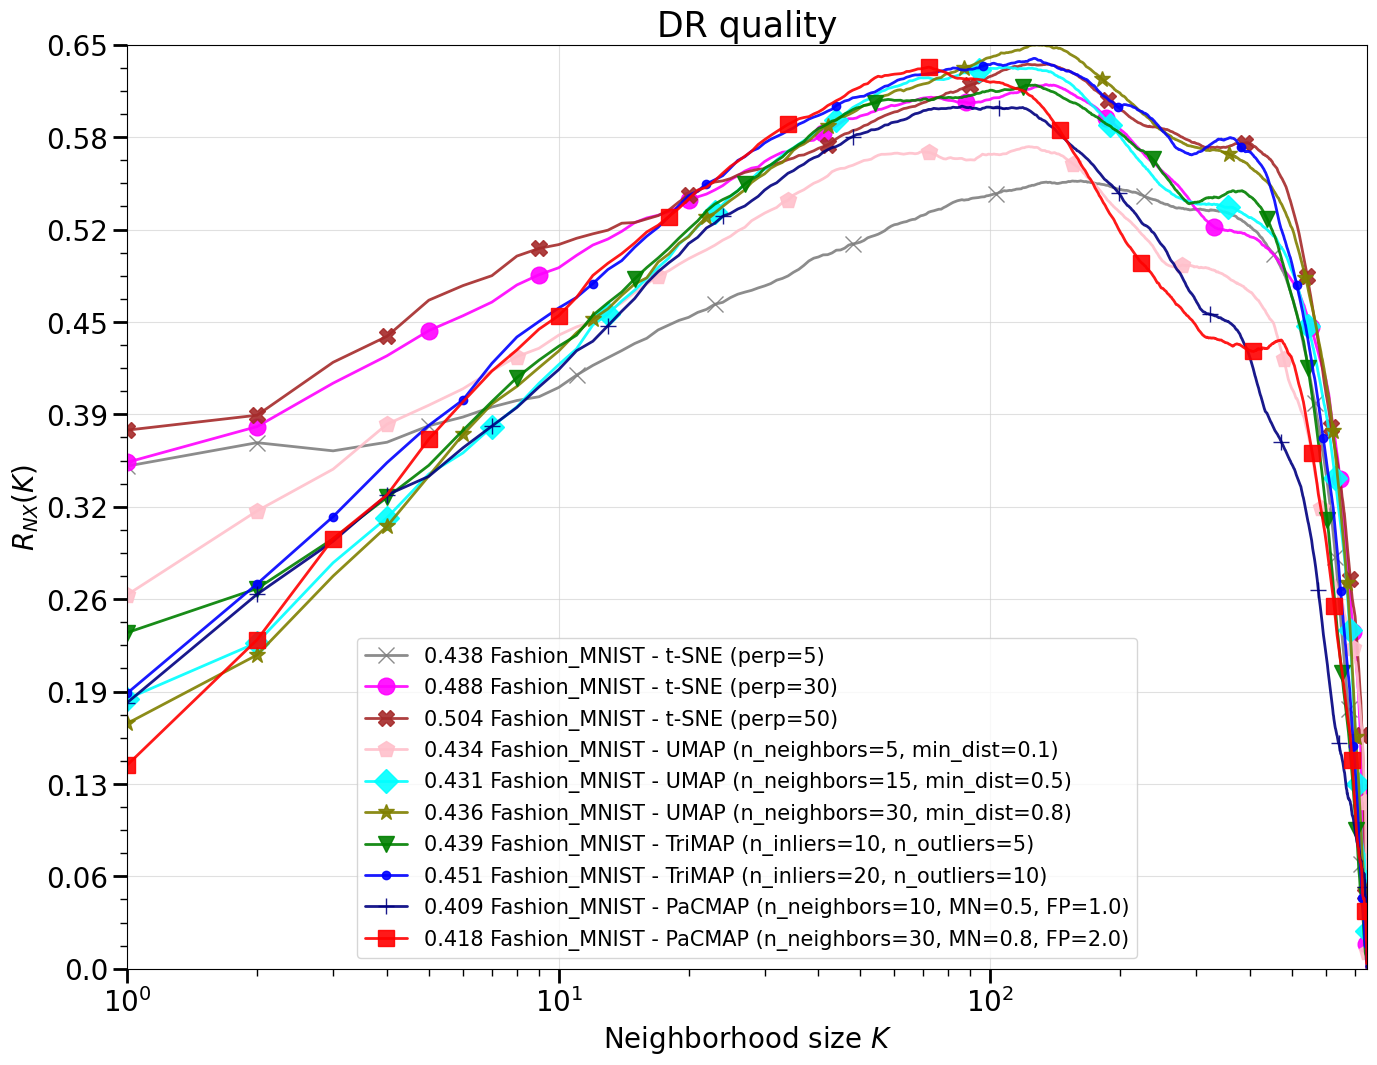

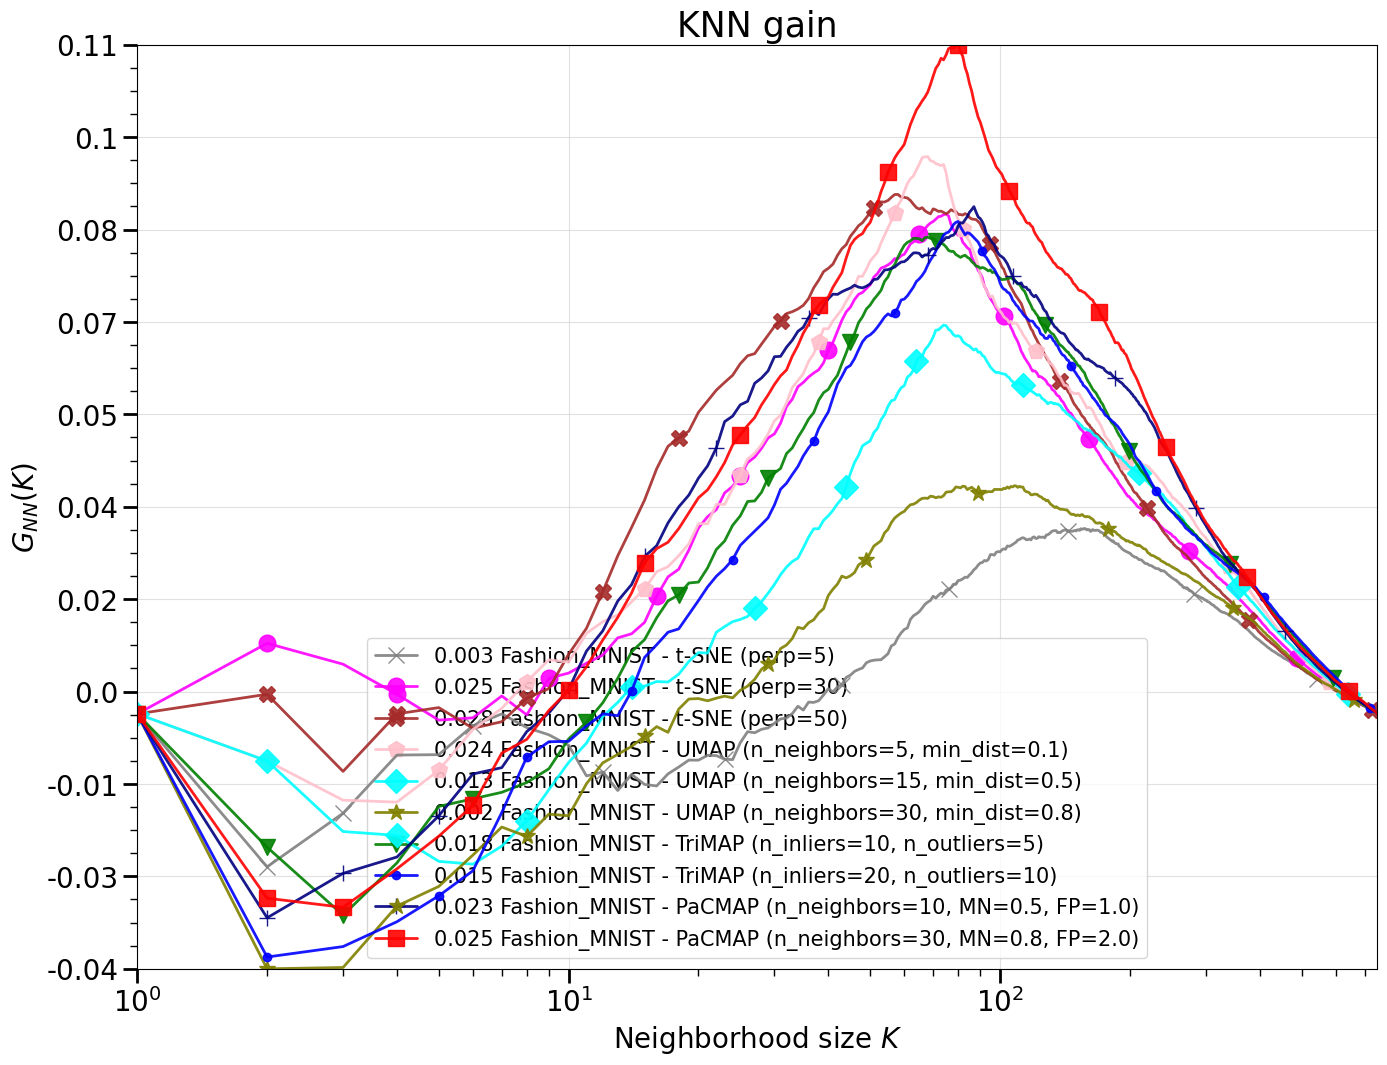

In [11]:
from evaluation_metrics import LocalMetric

def run_evaluation(X_hds, y, embeddings):
    metric_evaluator = LocalMetric()
    for name, X_lds in embeddings.items():
        metric_evaluator.calculate_knn_gain_and_dr_quality(
            X_lds=X_lds, X_hds=X_hds, labels=y, method_name=name
        )
    metric_evaluator.visualize()

if __name__ == "__main__":
    datasets = load_and_explore_data()
    
    for ds_name, (X, y) in datasets.items():
        X_sub, y_sub, embeddings = run_dr_methods(X, y, ds_name, sample_size=5000)
        
        best_method_key = list(embeddings.keys())[0]
        plot_enhanced_embedding(embeddings[best_method_key], X_sub, y_sub, best_method_key)
        
        run_evaluation(X_sub, y_sub, embeddings)

### Part 5: Analysis and Report

Write a comprehensive analysis (500-750 words) that addresses:

1. Which dimensionality reduction method best separates the classes in each dataset?
2. How do the optimal parameters differ between MNIST and Fashion MNIST?
3. Are certain classes consistently easier or harder to separate?
4. How do the quantitative metrics correlate with visual quality?
5. What are the trade-offs between the different methods in terms of:
- Computational efficiency
- Class separation
- Global structure preservation
- Sensitivity to hyperparameters


Dimensionality Reduction Performance and Class Separation

Based on the $G_{NN}(K)$ (KNN gain) charts, which directly measure how well local neighborhoods are preserved, PaCMAP and UMAP demonstrate the best class separation for both datasets.For MNIST, PaCMAP with parameters n_neighbors=10, MN=0.5, FP=1.0 achieves the highest peak in KNN gain, followed closely by UMAP (n_neighbors=5, min_dist=0.1). This indicates that these methods create the tightest, most distinct local clusters. In the Fashion MNIST dataset, PaCMAP (n_neighbors=30, MN=0.8, FP=2.0) significantly outperforms the other methods in peak KNN gain, making it the superior choice for handling the more complex, overlapping features of clothing items.


Optimal Parameters: MNIST vs. Fashion MNIST

MNIST represents a relatively simple manifold (distinct handwritten digits), whereas Fashion MNIST is far more complex, featuring higher intra-class variance and overlapping features.

Consequently, the optimal hyperparameters differ. For MNIST, smaller neighborhood sizes (e.g., t-SNE perp=30 or UMAP n_neighbors=15) are sufficient to capture the local structure without blurring distinct digit clusters together. Conversely, Fashion MNIST benefits from larger neighborhood sizes to capture the broader variance within clothing types. This is evident in the Fashion MNIST DR Quality chart, where t-SNE with perp=50 and PaCMAP with n_neighbors=30 maintain high $R_{NX}(K)$ scores across a much wider range of $K$ than their lower-parameter counterparts.


Class Separability Challenges

While the global metrics evaluate the dataset as a whole, visual scatter plots of these datasets historically reveal consistent challenges:

MNIST: Classes like '0' and '1' are structurally distinct and separate cleanly across almost all methods. However, '4', '7', and '9' share similar linear strokes and frequently bleed into one another. Similarly, '3' and '8' often form adjacent, slightly overlapping clusters.

Fashion MNIST: The separation difficulty is much more pronounced. Footwear items (sandals, sneakers, ankle boots) generally form a distinct macro-cluster separate from clothing. However, tops (T-shirts, shirts, pullovers, and coats) are notoriously difficult to separate. They share identical topological structures (a torso with sleeves) and heavily overlap in the embedding space regardless of the DR method used.


Correlation of Visual Quality and Quantitative Metrics

The provided evaluation metrics correlate directly with specific visual characteristics in the 2D scatter plots:

- KNN Gain ($G_{NN}(K)$): A high peak in this metric translates visually to "cluster tightness." Algorithms with high KNN gain (like PaCMAP and UMAP) will produce visual plots where points of the same class are densely packed together, with clear whitespace separating different classes.

- DR Quality ($R_{NX}(K)$): This metric evaluates structure preservation across different neighborhood sizes. High values at lower $K$ indicate good local structure, while high values at higher $K$ indicate good global structure. TriMAP and PaCMAP excel here, meaning that in their visual plots, the relative distances between different clusters are meaningful (e.g., similar digits are placed closer together on the canvas than highly dissimilar ones).


Trade-offs Between Methods

t-SNE: Computationally the most expensive and slowest to converge. It excels at local class separation but completely destroys global structure (clusters are placed arbitrarily). It is highly sensitive to the perplexity parameter.

UMAP: Significantly faster than t-SNE. It provides an excellent, tunable balance between local separation and global structure. It is, however, quite sensitive to its n_neighbors and min_dist parameters, which dictate cluster tightness.

TriMAP: Highly computationally efficient. It explicitly focuses on preserving global structure using triplets. The trade-off is that it can sometimes sacrifice the tight, neat local cluster boundaries seen in UMAP or t-SNE.

PaCMAP: Computationally efficient and generally requires the least hyperparameter tuning (its default parameters are highly robust). It achieves the best of both worlds by intelligently combining local and global structure preservation through its pair construction methodology, making it the most well-rounded method for these specific image datasets.